#### Central limit theorem 

Averaged 25 numbers per trial, 5,000,000 trials


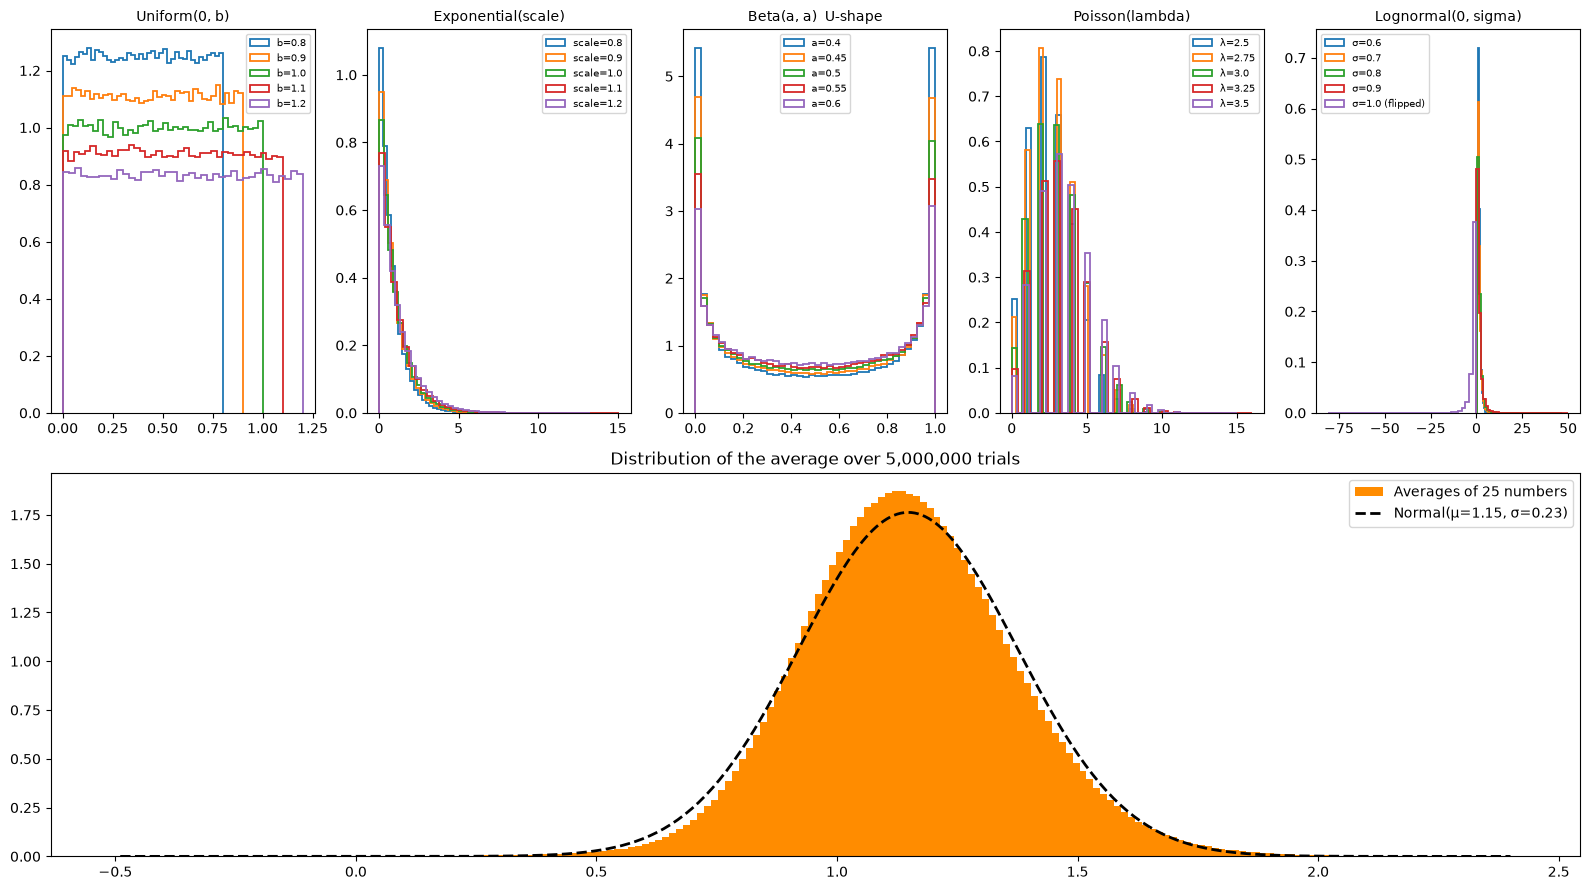

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N_TRIALS = 5_000_000
N_SHOW = 200_000          # how many samples to use for the top-row histograms

# 5 families x 5 slightly different parameter values = 25 distributions
families = {
    "Uniform(0, b)": {
        "params": [0.8, 0.9, 1.0, 1.1, 1.2],
        "sample": lambda p, n: rng.uniform(0, p, n),
        "label":  lambda p: f"b={p}",
    },
    "Exponential(scale)": {
        "params": [0.8, 0.9, 1.0, 1.1, 1.2],
        "sample": lambda p, n: rng.exponential(p, n),
        "label":  lambda p: f"scale={p}",
    },
    "Beta(a, a)  U-shape": {
        "params": [0.40, 0.45, 0.50, 0.55, 0.60],
        "sample": lambda p, n: rng.beta(p, p, n),
        "label":  lambda p: f"a={p}",
    },
    "Poisson(lambda)": {
        "params": [2.5, 2.75, 3.0, 3.25, 3.5],
        "sample": lambda p, n: rng.poisson(p, n),
        "label":  lambda p: f"λ={p}",
    },
    "Lognormal(0, sigma)": {
        "params": [0.6, 0.7, 0.8, 0.9, 1.0],
        "sample": lambda p, n: rng.lognormal(0, p, n),
        "label":  lambda p: f"σ={p}",
        "flip_params": [1.0],   # mirror (x -> -x) this variant so its right skew cancels the others
    },
}

# Each trial: draw ONE number from each of the 25 distributions, then average them.
# We keep a running sum so we never store a (5,000,000 x 25) array in memory.
total = np.zeros(N_TRIALS)
n_dists = 0
shown = {}   # small samples kept only for the top-row plots

for fam_name, fam in families.items():
    shown[fam_name] = []
    for p in fam["params"]:
        x = fam["sample"](p, N_TRIALS)
        flipped = p in fam.get("flip_params", [])
        if flipped:
            x = -x
        total += x
        n_dists += 1
        label = fam["label"](p) + (" (flipped)" if flipped else "")
        shown[fam_name].append((label, x[:N_SHOW]))

averages = total / n_dists
print(f"Averaged {n_dists} numbers per trial, {N_TRIALS:,} trials")

# --- Plot ---
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 5)

# Top row: one panel per family, overlaying its 5 parameter variants
for i, (fam_name, variants) in enumerate(shown.items()):
    ax = fig.add_subplot(gs[0, i])
    for label, data in variants:
        ax.hist(data, bins=40, density=True, histtype="step", lw=1.3, label=label)
    ax.set_title(fam_name, fontsize=10)
    ax.legend(fontsize=7)

# Bottom row: histogram of the averages + normal curve with the same mean/std
ax = fig.add_subplot(gs[1, :])
lo, hi = np.percentile(averages, [0.01, 99.99])   # zoom past rare extreme values
ax.hist(averages, bins=200, range=(lo, hi), density=True, color="darkorange",
        label=f"Averages of {n_dists} numbers")

mu, sigma = averages.mean(), averages.std()
x = np.linspace(lo, hi, 400)
pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, pdf, "k--", lw=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")

ax.set_title(f"Distribution of the average over {N_TRIALS:,} trials")
ax.legend()

plt.tight_layout()
plt.savefig("clt_demo_25.png", dpi=120)
plt.show()

# Moments, MGF, Cumulants and the Characteristic Function

*Complete study notes, rebuilt in a logical order. Every formula is derived from something defined earlier.*

## Roadmap: the whole story in one paragraph

Moments describe the shape of a distribution (location, spread, asymmetry, tail weight). The **MGF** packs all moments into one function, and it turns sums of independent variables into simple products. But the MGF needs light tails, so it **fails** for heavy-tailed variables (Cauchy, lognormal). The fix is the **characteristic function**, which uses an imaginary exponent, always exists, keeps every good property, and gives a clean proof of the Central Limit Theorem.

```
moments -> MGF (stores moments, can fail)
              | ln
           cumulants (add over independent sums) -> skewness, excess kurtosis
              |
           characteristic function (always exists) -> CLT via Levy's theorem
```

**Order of the notes**

1. Prerequisites
2. Moments (raw, central, standardized)
3. Shape measures: skewness, kurtosis, and properties of common distributions
4. The Moment Generating Function and how moments come out of it
5. MGF of sums and linear combinations (X + Y and friends)
6. Cumulants
7. Advantages of the MGF, its limitations, and exactly why it fails
8. The Characteristic Function: definition and intuition
9. CF properties with full proofs
10. CF examples
11. Inversion, uniqueness, Levy's continuity theorem
12. CLT proof and speed of convergence
13. Cheat sheet
14. Code to verify everything

**Notation.** `X, Y` random variables; `E[.]` expectation; `Var` variance; `mu = E[X]`; `sigma^2 = Var(X)`; `i` the imaginary unit, `i^2 = -1`; `iid` = independent and identically distributed.

---

## 1. Prerequisites

### 1.1 Expected value

```
Discrete:   E[X] = sum_x  x * p(x)
Continuous: E[X] = integral  x * f(x) dx
```

### 1.2 Expectation of a function (LOTUS)

To get `E[g(X)]` you do not need the distribution of `g(X)`; plug `g` inside:

```
E[g(X)] = sum_x g(x) p(x)          (discrete)
E[g(X)] = integral g(x) f(x) dx    (continuous)
```

This is how we compute `E[X^2]`, `E[e^{tX}]` and `E[e^{itX}]`.

### 1.3 Linearity (always true, no independence needed)

```
E[aX + bY + c] = a E[X] + b E[Y] + c
```

### 1.4 Independence gives a product rule

If `X` and `Y` are independent, then for any functions `g, h`:

```
E[ g(X) h(Y) ] = E[g(X)] * E[h(Y)]
```

This single fact is why MGFs and characteristic functions are so powerful for sums.

### 1.5 Variance, covariance

```
Var(X) = E[(X - mu)^2]
       = E[X^2 - 2 mu X + mu^2]
       = E[X^2] - 2 mu^2 + mu^2          (linearity)
       = E[X^2] - mu^2

Cov(X,Y) = E[(X - mu_X)(Y - mu_Y)] = E[XY] - E[X]E[Y]
Var(X + Y) = Var(X) + Var(Y) + 2 Cov(X,Y)
```

If `X, Y` are independent then `Cov = 0`, so `Var(X+Y) = Var(X) + Var(Y)`. The converse is false: zero covariance does not imply independence.

### 1.6 The exponential series

For any real or complex `x`:

```
e^x = 1 + x + x^2/2! + x^3/3! + ... = sum_{k>=0} x^k / k!
```

### 1.7 Markov's inequality

For a random variable `U >= 0` and `a > 0`: `P(U >= a) <= E[U] / a`.

*Proof.* Pointwise, `a * 1{U >= a} <= U` (if `U >= a` the left side is `a <= U`; otherwise it is `0 <= U`). Take expectations: `a P(U >= a) <= E[U]`. QED

We will use it for the Chernoff bound (MGF) and for tightness (CF).

---

## 2. Moments

### 2.1 Definitions

| Name | Formula | Meaning |
| --- | --- | --- |
| k-th **raw moment** | `m'_k = E[X^k]` | average of the k-th power |
| k-th **central moment** | `m_k = E[(X - mu)^k]` | average k-th power of the distance from the mean |
| k-th **standardized moment** | `m_k / sigma^k` | central moment made unit-free |

Special cases:

- `m'_1 = mu` (mean)
- `m_1 = 0` always, since `E[X - mu] = mu - mu = 0`
- `m_2 = sigma^2` (variance)
- `m_3 / sigma^3` = **skewness**
- `m_4 / sigma^4` = **kurtosis**

### 2.2 What each moment tells you

| Moment | Describes | Why |
| --- | --- | --- |
| 1st (raw) | location | the balance point of the distribution |
| 2nd (central) | spread | squares make all deviations positive |
| 3rd (central) | asymmetry | the cube keeps the sign: left deviations count negative, right deviations positive |
| 4th (central) | tail weight / outlier-proneness | the fourth power makes far-away values count enormously |

### 2.3 When do moments exist?

The k-th moment exists when `E|X|^k < infinity`. Higher moments imply lower ones:

**Claim.** If `E|X|^k < infinity` then `E|X|^j < infinity` for every `j < k`.

*Proof.* For all real `x`, `|x|^j <= 1 + |x|^k` (if `|x| <= 1` then `|x|^j <= 1`; if `|x| > 1` then `|x|^j <= |x|^k`). Take expectations: `E|X|^j <= 1 + E|X|^k < infinity`. QED

So a finite variance guarantees a finite mean. The converse fails: a distribution can have a mean but no variance (for example a Student t with 2 degrees of freedom, or a Pareto with tail index between 1 and 2).

### 2.4 Effect of shifting and scaling

Let `Y = aX + b`. Then

```
E[Y] = a mu + b
Var(Y) = a^2 sigma^2
m_k(Y) = E[(aX + b - a mu - b)^k] = a^k m_k(X)      (central moments ignore the shift b)
```

Consequence: the standardized moment `m_k / sigma^k` of `Y` equals `(a^k m_k) / (|a|^k sigma^k)`, which equals the same value as for `X` when `a > 0` (and flips sign for odd `k` when `a < 0`). So standardized moments are unit-free, and that is why skewness and kurtosis are used to compare shapes.

### 2.5 Converting raw moments to central moments

Expand `(X - mu)^k` with the binomial theorem and use linearity:

```
m_k = sum_{j=0}^{k} C(k,j) (-mu)^{k-j} m'_j
```

Explicitly (write `m'_j = E[X^j]`):

```
m_2 = m'_2 - mu^2

m_3 = E[X^3 - 3 mu X^2 + 3 mu^2 X - mu^3]
    = m'_3 - 3 mu m'_2 + 3 mu^3 - mu^3
    = m'_3 - 3 mu m'_2 + 2 mu^3

m_4 = E[X^4 - 4 mu X^3 + 6 mu^2 X^2 - 4 mu^3 X + mu^4]
    = m'_4 - 4 mu m'_3 + 6 mu^2 m'_2 - 4 mu^4 + mu^4
    = m'_4 - 4 mu m'_3 + 6 mu^2 m'_2 - 3 mu^4
```

### 2.6 Worked example: moments by direct integration (Exponential)

Let `X ~ Exponential(rate lambda)`, density `f(x) = lambda e^{-lambda x}`, `x >= 0`.

```
E[X^k] = integral_0^inf x^k lambda e^{-lambda x} dx
```

Integrate by parts with `u = x^k`, `dv = lambda e^{-lambda x} dx`:

```
E[X^k] = [ -x^k e^{-lambda x} ]_0^inf + integral_0^inf k x^{k-1} e^{-lambda x} dx
       = 0 + (k/lambda) * E[X^{k-1}]
```

With `E[X^0] = 1` this gives by induction `E[X^k] = k! / lambda^k`. So

```
E[X] = 1/lambda, E[X^2] = 2/lambda^2, E[X^3] = 6/lambda^3, E[X^4] = 24/lambda^4
```

Central moments from section 2.5 with `mu = 1/lambda`:

```
sigma^2 = 2/lambda^2 - 1/lambda^2 = 1/lambda^2
m_3 = 6/lambda^3 - 3(1/lambda)(2/lambda^2) + 2/lambda^3 = 2/lambda^3
m_4 = 24/lambda^4 - 4(1/lambda)(6/lambda^3) + 6(1/lambda^2)(2/lambda^2) - 3/lambda^4 = 9/lambda^4

Skewness = m_3/sigma^3 = 2
Kurtosis = m_4/sigma^4 = 9     (excess = 6)
```

This is the hard way (one integral per moment). The MGF in section 4 gets all of them at once.

---

## 3. Shape measures: skewness, kurtosis and properties of distributions

### 3.1 Skewness

```
gamma_1 = E[(X - mu)^3] / sigma^3
```

| Value | Meaning |
| --- | --- |
| `gamma_1 = 0` | symmetric, or tails that balance out |
| `gamma_1 > 0` | long **right** tail (a few very large values); mean usually above median |
| `gamma_1 < 0` | long **left** tail; mean usually below median |

**Why divide by sigma^3?** To make it unit-free. By 2.4, multiplying `X` by `c > 0` multiplies `m_3` by `c^3` and `sigma^3` by `c^3`, so `gamma_1` is unchanged. Changing units (metres to centimetres, dollars to rupees) must not change the shape.

**Symmetry implies zero skewness.** If `X` is symmetric about `mu` (so `X - mu` and `mu - X` have the same distribution) and `m_3` exists, then `E[(X-mu)^3] = E[(mu-X)^3] = -E[(X-mu)^3]`, so it equals 0.

**Warning: zero skewness does not imply symmetry.** Zero only says the cubed deviations cancel; many asymmetric distributions achieve this. Also, the rule 'mean > median when skewed right' is a rule of thumb, not a theorem.

### 3.2 Kurtosis and excess kurtosis

```
Kurtosis        = E[(X - mu)^4] / sigma^4
Excess kurtosis = Kurtosis - 3
```

The normal distribution has kurtosis 3 (proved in section 4.5), so excess kurtosis 0 means 'same tail weight as a normal'.

| Excess kurtosis | Name | Meaning | Examples |
| --- | --- | --- | --- |
| `< 0` | platykurtic | lighter tails than normal | uniform, Bernoulli(1/2) |
| `= 0` | mesokurtic | normal-like | normal |
| `> 0` | leptokurtic | heavier tails, more outliers | exponential, Laplace, Student t |

**Misconception: kurtosis is NOT 'peakedness'.** Because of the fourth power, kurtosis is dominated by the extreme tails. It measures the **tendency to produce outliers**.

**Worked numerical example (one outlier dominates).** Let `X` take values `0, 1, 2, 10` with probabilities `0.4, 0.3, 0.2, 0.1`.

```
mu     = 0(0.4) + 1(0.3) + 2(0.2) + 10(0.1)        = 1.7
E[X^2] = 0 + 0.3 + 0.8 + 10                          = 11.1
sigma^2 = 11.1 - 1.7^2                               = 8.21
E[X^3] = 0.3 + 1.6 + 100                             = 101.9
E[X^4] = 0.3 + 3.2 + 1000                            = 1003.5

m_3 = 101.9 - 3(1.7)(11.1) + 2(1.7)^3 = 55.12     -> skewness = 55.12 / 8.21^{1.5} = 2.34
m_4 = 1003.5 - 4(1.7)(101.9) + 6(1.7)^2(11.1) - 3(1.7)^4 = 478.0
                                                    -> kurtosis = 478.0 / 8.21^2 = 7.09, excess = 4.09
```

The single value `x = 10` contributes `0.1 * (10 - 1.7)^4 = 474.6` to `m_4`, which is **99%** of it. That is what 'kurtosis measures tails' means.

### 3.3 Limits on skewness and kurtosis

**Claim.** `Kurtosis >= 1 + gamma_1^2`, hence excess kurtosis `>= -2`.

*Proof.* Let `Y = (X - mu)/sigma`, so `E[Y] = 0`, `E[Y^2] = 1`, `E[Y^3] = gamma_1`, `E[Y^4] = Kurtosis`. The squared correlation of any two variables is at most 1, i.e. `Cov(Y^2, Y)^2 <= Var(Y^2) Var(Y)`. Compute:

```
Cov(Y^2, Y) = E[Y^3] - E[Y^2]E[Y] = gamma_1
Var(Y)      = 1
Var(Y^2)    = E[Y^4] - (E[Y^2])^2 = Kurtosis - 1
```

So `gamma_1^2 <= Kurtosis - 1`. Since `gamma_1^2 >= 0`, Kurtosis `>= 1`. QED

Equality holds for two-point distributions; Bernoulli(1/2) (a fair coin) has kurtosis 1 and excess kurtosis exactly `-2`. There is no upper limit on kurtosis (heavy tails can make it huge or infinite).

### 3.4 Reference table of common distributions

| Distribution | Mean | Variance | Skewness | Excess kurtosis |
| --- | --- | --- | --- | --- |
| Normal `N(mu, sigma^2)` | `mu` | `sigma^2` | 0 | 0 |
| Uniform(a, b) | `(a+b)/2` | `(b-a)^2/12` | 0 | `-6/5 = -1.2` |
| Exponential(rate `lambda`) | `1/lambda` | `1/lambda^2` | 2 | 6 |
| Gamma(shape k, scale theta) | `k theta` | `k theta^2` | `2/sqrt(k)` | `6/k` |
| Laplace | `mu` | `2b^2` | 0 | 3 |
| Poisson(`lambda`) | `lambda` | `lambda` | `1/sqrt(lambda)` | `1/lambda` |
| Bernoulli(p) | `p` | `p(1-p)` | `(1-2p)/sqrt(p(1-p))` | `(1 - 6p(1-p)) / (p(1-p))` |
| Binomial(n, p) | `np` | `np(1-p)` | `(1-2p)/sqrt(np(1-p))` | `(1 - 6p(1-p)) / (np(1-p))` |
| Chi-square(k) | `k` | `2k` | `sqrt(8/k)` | `12/k` |
| Beta(a, a) | `1/2` | `1/(4(2a+1))` | 0 | `-6/(2a+3)` |
| Student t (nu > 4) | 0 | `nu/(nu-2)` | 0 | `6/(nu-4)` |
| Lognormal(0, s) | `e^{s^2/2}` | `(e^{s^2}-1) e^{s^2}` | `(e^{s^2}+2) sqrt(e^{s^2}-1)` | `e^{4s^2} + 2e^{3s^2} + 3e^{2s^2} - 6` |

Checks: Beta(1,1) is Uniform(0,1), and `-6/(2*1+3) = -1.2` matches. Student t has no kurtosis for `nu <= 4`, no variance for `nu <= 2`, no mean for `nu <= 1` (the Cauchy is `nu = 1`).

### 3.5 Estimating from data

With sample central moments `m_k = (1/n) sum (x_j - xbar)^k`:

```
sample skewness        g_1 = m_3 / m_2^{3/2}
sample excess kurtosis g_2 = m_4 / m_2^2 - 3
```

In scipy: `scipy.stats.skew(data)` and `scipy.stats.kurtosis(data)` (the latter returns **excess** kurtosis by default). Both are biased in small samples, and for heavy-tailed data they are extremely noisy because they depend on a handful of extreme observations (see the 99% example above).

### 3.6 Other terms you will meet

| Term | Definition |
| --- | --- |
| **PDF / PMF** | density `f(x)` (continuous) or probabilities `p(x)` (discrete) |
| **CDF** | `F(x) = P(X <= x)` |
| **Median** | value `m` with `P(X <= m) >= 1/2` and `P(X >= m) >= 1/2` |
| **Mode** | most likely value (peak of the density) |
| **Quantile** | value below which a given fraction of the probability lies |
| **Standardization** | `Z = (X - mu)/sigma`, giving mean 0 and variance 1 |
| **Covariance / correlation** | linear co-movement of two variables (section 1.5) |
| **Convergence in probability** | `P(abs(X_n - X) > eps) -> 0` for every `eps > 0` |
| **Convergence in distribution** | `F_{X_n}(x) -> F_X(x)` at every continuity point of `F_X`; the mode of convergence in the CLT |
| **Law of Large Numbers** | the sample mean converges to the number `mu`; the CLT describes the **shape of the fluctuations** around it |

### 3.7 The moment problem (why one more tool is needed)

A natural question: do the moments `E[X], E[X^2], ...` determine the distribution? Not always. The lognormal has all moments, yet there are other distributions with exactly the same moment sequence. So moments alone can fail to identify a distribution. Generating functions (next section) give an identification tool that works under a growth condition on the moments, and the characteristic function (section 8) works always.

---

## 4. The Moment Generating Function (MGF)

### 4.1 The idea

Section 2.6 computed each moment with a separate integral. We want to store **all** moments `E[X], E[X^2], E[X^3], ...` in **one** function and get any of them back by a simple operation. Such a function is a *generating function*, and for moments it is the MGF.

### 4.2 Definition

```
M_X(t) = E[ e^{tX} ]
```

For a continuous variable this is `integral e^{tx} f(x) dx`; for a discrete one it is `sum e^{tx} p(x)`.

**Existence condition.** We say the MGF *exists* only if `M_X(t)` is finite for all `t` in some open interval `(-h, h)` around 0, with `h > 0`. Being finite only at `t = 0` is not enough (there it always equals 1).

### 4.3 Why `e^{tX}` stores the moments

Put `x = tX` in the exponential series (1.6):

```
e^{tX} = 1 + tX + t^2 X^2/2! + t^3 X^3/3! + ...
```

Take expectations term by term:

```
M_X(t) = 1 + t E[X] + t^2 E[X^2]/2! + t^3 E[X^3]/3! + ...
       = sum_{k>=0}  E[X^k] t^k / k!
```

The moments are the coefficients of the power series of `M_X`, each divided by `k!`. That `k!` is the 'price' of packing them in; it is why the function is called *generating*.

### 4.4 Theorem: moments are derivatives at 0

**Statement.** If `M_X(t)` exists on `(-h, h)`, then every moment is finite and

```
E[X^k] = M_X^{(k)}(0)       (the k-th derivative of M at t = 0)
```

**Proof.**

*Step 1: justify swapping E and the infinite sum.* The swap is allowed (Fubini/Tonelli) if the sum of absolute values has finite expectation:

```
sum_k |tX|^k / k!  =  e^{|tX|}
E[ e^{|tX|} ] <= E[ e^{tX} + e^{-tX} ] = M(t) + M(-t) < infinity     for |t| < h
```

The inequality holds because `e^{|y|}` equals either `e^{y}` or `e^{-y}`, both positive. So the swap is valid. The same bound also shows `E|X|^k <= k! * (M(t) + M(-t)) / t^k < infinity` for every `k`, since `|tX|^k/k! <= e^{|tX|}`.

*Step 2: identify coefficients.* After the swap, `M(t) = sum_k [E[X^k]/k!] t^k` on `(-h, h)`.

*Step 3: differentiate the power series.* Inside its radius of convergence a power series can be differentiated term by term. Differentiating `k` times and putting `t = 0` kills every term except the k-th:

```
M^{(k)}(0) = k! * (coefficient of t^k) = k! * E[X^k]/k! = E[X^k]        QED
```

**Quick intuition (first derivative).** Differentiating inside the expectation: `d/dt E[e^{tX}] = E[X e^{tX}]`, and at `t = 0` this is `E[X]`. The second derivative gives `E[X^2 e^{tX}]`, which at 0 is `E[X^2]`.

**Recipe.**

1. Compute `M(t)`.
2. Differentiate `k` times (or expand it as a power series and read off coefficients).
3. Set `t = 0`. Mean `= M'(0)`, variance `= M''(0) - M'(0)^2`.

### 4.5 Basic properties, each proved

**(a) `M(0) = 1`.** Because `e^{0 * X} = 1` and `E[1] = 1`.

**(b) Linear transformation.** For `Y = aX + b`:

```
M_Y(t) = E[e^{t(aX + b)}] = e^{bt} E[e^{(at)X}] = e^{bt} M_X(at)
```

**(c) Sum of independent variables (the key property).** Proved in section 5.

**(d) Uniqueness (stated).** If `M_X(t) = M_Y(t)` for all `t` in some interval `(-h, h)`, then `X` and `Y` have the same distribution. *Why true (idea):* a function given by a convergent power series is analytic, so it extends to complex `t`; on the imaginary axis it becomes the characteristic function (section 8), and the characteristic function determines the distribution (section 11).

**(e) Continuity (stated).** If `M_{X_n}(t) -> M_X(t)` for all `t` in an interval around 0, then `X_n -> X` in distribution.

**(f) Convexity and positivity.** `M(t) > 0` always, and `M` is convex (its second derivative `E[X^2 e^{tX}] >= 0`). Equivalent statement: `ln M` is also convex, which gives `K''(t) >= 0` for the cumulant generating function (section 6).

### 4.6 Worked MGF examples

**Bernoulli(p).** `X = 1` with probability `p`, else 0.

```
M(t) = e^{0}(1 - p) + e^{t} p = 1 - p + p e^t
```

`M'(0) = p` (mean), `M''(0) = p` so `Var = p - p^2 = p(1-p)`. Binomial(n, p) is a sum of `n` independent Bernoullis, so `M(t) = (1 - p + p e^t)^n` (section 5).

**Poisson(lambda).**

```
M(t) = sum_k e^{tk} e^{-lambda} lambda^k / k!
     = e^{-lambda} sum_k (lambda e^t)^k / k!
     = e^{-lambda} exp(lambda e^t)             (exponential series, x = lambda e^t)
     = exp( lambda (e^t - 1) )                 (finite for all t)
```

Moments:

```
M'(t)  = lambda e^t M(t)                       ->  M'(0)  = lambda       (mean)
M''(t) = lambda e^t M(t) + (lambda e^t)^2 M(t) ->  M''(0) = lambda + lambda^2
Var    = E[X^2] - mu^2 = lambda + lambda^2 - lambda^2 = lambda
```

**Exponential(rate lambda).**

```
M(t) = integral_0^inf e^{tx} lambda e^{-lambda x} dx
     = lambda integral_0^inf e^{-(lambda - t)x} dx
     = lambda / (lambda - t)                    valid only for t < lambda
```

It exists only for `t < lambda`, which is still an open interval around 0, so it qualifies. Expand as a geometric series:

```
lambda/(lambda - t) = 1/(1 - t/lambda) = sum_k (t/lambda)^k
```

Compare with `sum E[X^k] t^k / k!`: `E[X^k]/k! = 1/lambda^k`, so `E[X^k] = k!/lambda^k`. This matches the integration-by-parts result of section 2.6 with a single line of work.

**Standard normal N(0,1).**

```
M(t) = integral e^{tx} (1/sqrt(2 pi)) e^{-x^2/2} dx
     = integral (1/sqrt(2 pi)) e^{-(x^2 - 2tx)/2} dx
```

Complete the square: `x^2 - 2tx = (x - t)^2 - t^2`. So

```
M(t) = e^{t^2/2} * integral (1/sqrt(2 pi)) e^{-(x - t)^2/2} dx
     = e^{t^2/2} * 1            (the integrand is a normal density, total area 1)
     = e^{t^2/2}
```

*All moments of the standard normal.* Expand `e^{t^2/2}`:

```
e^{t^2/2} = sum_k (t^2/2)^k / k! = sum_k t^{2k} / (2^k k!)
```

Only even powers appear, so **all odd moments are 0**. Matching the coefficient of `t^{2k}` with `E[Z^{2k}]/(2k)!`:

```
E[Z^{2k}] = (2k)! / (2^k k!) = (2k-1)!! = 1 * 3 * 5 * ... * (2k-1)
```

So `E[Z^2] = 1`, `E[Z^4] = 3`, `E[Z^6] = 15`. Therefore the normal has **skewness 0** and **kurtosis 3**, which is why we subtract 3 to get excess kurtosis.

**General normal N(mu, sigma^2).** Write `X = mu + sigma Z` and use property (b):

```
M_X(t) = e^{mu t} M_Z(sigma t) = exp( mu t + sigma^2 t^2 / 2 )
```

Check: `M'(t) = (mu + sigma^2 t) M(t)` gives `M'(0) = mu`; `M''(t) = sigma^2 M(t) + (mu + sigma^2 t)^2 M(t)` gives `M''(0) = sigma^2 + mu^2`, so `Var = sigma^2`.

**Uniform(0,1).** `M(t) = integral_0^1 e^{tx} dx = (e^t - 1)/t` for `t != 0`, and `M(0) = 1`. (Expand `(e^t - 1)/t = 1 + t/2! + t^2/3! + ...` to read `E[X^k] = 1/(k+1)`.)

**Gamma(shape k, rate lambda).** `M(t) = (lambda/(lambda - t))^k` for `t < lambda`. This is the k-th power of the exponential MGF, which is no accident (section 5.4).

---

## 5. MGF of sums and combinations of variables (X + Y and more)

This is where the MGF earns its keep. Finding the distribution of `X + Y` directly needs a convolution integral; with MGFs it is a product.

### 5.1 Theorem: independent sum = product of MGFs

If `X` and `Y` are independent and both MGFs exist near 0:

```
M_{X+Y}(t) = E[ e^{t(X+Y)} ]
           = E[ e^{tX} * e^{tY} ]          (exponent rule)
           = E[e^{tX}] * E[e^{tY}]         (independence, section 1.4)
           = M_X(t) * M_Y(t)               QED
```

### 5.2 Extensions

**n independent variables:** `M_{X_1 + ... + X_n}(t) = M_{X_1}(t) * ... * M_{X_n}(t)`.

**n iid copies:** `M_{S_n}(t) = [M_X(t)]^n`.

**General linear combination.** For independent `X_i`, constants `a_i`, `b`:

```
M_{b + sum a_i X_i}(t) = e^{bt} * prod_i M_{X_i}(a_i t)
```

*Proof.* Combine property 4.5(b) (scaling each term) with the product rule.

**Difference.** `X - Y = X + (-1)Y`, so `M_{X-Y}(t) = M_X(t) M_Y(-t)`. (Note the minus sign inside; the MGFs do **not** divide.)

**Sample mean.** `Xbar = (1/n) S_n`, so `M_{Xbar}(t) = [M_X(t/n)]^n`.

### 5.3 The recipe for any sum problem

1. Write down each MGF.
2. Multiply (with scaling `t -> a_i t` where needed).
3. Recognise the result as a known MGF.
4. By **uniqueness** (4.5(d)) the sum has that distribution.

### 5.4 Worked examples

**Sum of independent Poissons is Poisson.** With `X ~ Poisson(lambda_1)`, `Y ~ Poisson(lambda_2)`:

```
M_{X+Y}(t) = exp(lambda_1 (e^t - 1)) * exp(lambda_2 (e^t - 1)) = exp((lambda_1 + lambda_2)(e^t - 1))
```

This is the MGF of Poisson(`lambda_1 + lambda_2`), so `X + Y ~ Poisson(lambda_1 + lambda_2)`.

**Sum of independent normals is normal.** For independent `N(mu_1, sigma_1^2)` and `N(mu_2, sigma_2^2)`:

```
M_{X+Y}(t) = exp( (mu_1 + mu_2) t + (sigma_1^2 + sigma_2^2) t^2 / 2 )
```

So `X + Y ~ N(mu_1 + mu_2, sigma_1^2 + sigma_2^2)`. For a general combination `aX + bY` you get `N(a mu_1 + b mu_2, a^2 sigma_1^2 + b^2 sigma_2^2)`.

**Sample mean of normals.** For `X_i` iid `N(mu, sigma^2)`: `M_{Xbar}(t) = [exp(mu t/n + sigma^2 t^2/(2n^2))]^n = exp(mu t + (sigma^2/n) t^2/2)`, so `Xbar ~ N(mu, sigma^2/n)` **exactly** (not just approximately).

**Binomial from Bernoullis.** `M_{S_n}(t) = (1 - p + p e^t)^n`, the Binomial(n, p) MGF.

**Sum of exponentials is Gamma.** For `n` iid Exponential(`lambda`): `M(t) = (lambda/(lambda - t))^n`, the Gamma(n, rate `lambda`) MGF. So the waiting time for the n-th event of a Poisson process is Gamma.

**Sum of squares of normals is chi-square.** For `Z ~ N(0,1)`, `M_{Z^2}(t) = E[e^{t Z^2}] = (1 - 2t)^{-1/2}` for `t < 1/2` (complete the square again in the integral). For `n` independent copies the MGF is `(1 - 2t)^{-n/2}`, the chi-square(n) MGF.

### 5.5 Mean and variance of a sum from the MGF

From `M_S = prod M_i`, take `ln`: `K_S = sum K_i` (section 6). Differentiating at 0 gives, for independent terms,

```
E[S] = sum E[X_i]        Var(S) = sum Var(X_i)
```

The mean statement needs no independence (linearity); the variance statement does.

### 5.6 Random sums (compound distributions)

Let `S = X_1 + ... + X_N` where `N` is a random count independent of the iid `X_i`. Condition on `N`:

```
M_S(t) = E[ E[e^{tS} | N] ] = E[ M_X(t)^N ] = E[ e^{N ln M_X(t)} ] = M_N( ln M_X(t) )
```

Example: if `N ~ Poisson(lambda)` then `M_S(t) = exp( lambda (M_X(t) - 1) )` (compound Poisson, used in insurance and queueing).

### 5.7 When the product rule does NOT apply

- **Dependent variables.** If `Y = X`, then `M_{2X}(t) = M_X(2t)`, which is not `M_X(t)^2` in general. The product rule needs independence.
- **The converse is false.** There are special dependent pairs for which `M_{X+Y} = M_X M_Y` still holds, so the product identity alone does not prove independence.
- **Correct tool for dependent variables:** the *joint* MGF `M_{X,Y}(s,t) = E[e^{sX + tY}]`. It factorises as `M_X(s) M_Y(t)` for all `s, t` near 0 if and only if `X` and `Y` are independent. Setting `s = t` gives the MGF of `X + Y`.

---

## 6. Cumulants and the Cumulant Generating Function

### 6.1 Definition

```
K_X(t) = ln M_X(t)           (cumulant generating function, CGF)
kappa_r = K_X^{(r)}(0)       (r-th cumulant),   so   K(t) = sum_r kappa_r t^r / r!
```

### 6.2 Why cumulants are useful (four properties, proved)

**Property 1: cumulants of independent sums add.** From `M_{X+Y} = M_X M_Y`, take logs:

```
K_{X+Y}(t) = K_X(t) + K_Y(t)     ->     kappa_r(X + Y) = kappa_r(X) + kappa_r(Y)
```

Moments do **not** add this way; cumulants do. That is the whole reason they exist.

**Property 2: scaling.** `K_{cX}(t) = ln M_X(ct) = K_X(ct)`, so `kappa_r(cX) = c^r kappa_r(X)`.

**Property 3: shifting only changes kappa\_1.** `K_{X+b}(t) = K_X(t) + bt`, and `bt` is a linear term, so only `kappa_1` changes (by `b`). Every cumulant with `r >= 2` is shift-invariant.

**Property 4: the normal has no cumulants beyond the second.** For `N(mu, sigma^2)`: `K(t) = mu t + sigma^2 t^2/2`, so `kappa_1 = mu`, `kappa_2 = sigma^2`, and `kappa_r = 0` for `r >= 3`. That is why skewness and excess kurtosis measure 'departure from normal'.

### 6.3 The first four cumulants

**First two, by derivatives.**

```
K'(t)  = M'(t)/M(t)                   ->  K'(0)  = E[X]/1       = mu         = kappa_1
K''(t) = [M'' M - (M')^2] / M^2       ->  K''(0) = E[X^2] - mu^2 = sigma^2   = kappa_2
```

**kappa\_3 and kappa\_4, by series (cleanest route).** By Property 3, `kappa_r` for `r >= 2` is unchanged if we centre the variable. Let `Y = X - mu` with `m_1 = 0`. Its MGF series is

```
M_Y(t) = 1 + u,     u = m_2 t^2/2 + m_3 t^3/6 + m_4 t^4/24 + ...
```

Use `ln(1 + u) = u - u^2/2 + u^3/3 - ...`. Up to order `t^4`, only `u` and `u^2` matter and `u^2 = m_2^2 t^4/4 + (higher order)`. So

```
K_Y(t) = m_2 t^2/2 + m_3 t^3/6 + ( m_4/24 - m_2^2/8 ) t^4 + O(t^5)
```

Match with `sum kappa_r t^r / r!`:

```
kappa_2 = 2! * (m_2/2)             = m_2
kappa_3 = 3! * (m_3/6)             = m_3
kappa_4 = 4! * (m_4/24 - m_2^2/8) = m_4 - 3 m_2^2
```

| Cumulant | Equals |
| --- | --- |
| `kappa_1` | mean |
| `kappa_2` | variance `sigma^2` |
| `kappa_3` | third central moment `m_3` |
| `kappa_4` | `m_4 - 3 sigma^4` |

Hence

```
Skewness        gamma_1 = kappa_3 / kappa_2^{3/2}
Excess kurtosis gamma_2 = kappa_4 / kappa_2^2
```

Check: `kappa_4/kappa_2^2 = (m_4 - 3 sigma^4)/sigma^4 = Kurtosis - 3`. This is the formal reason behind 'excess' kurtosis: it is the standardized fourth cumulant.

### 6.4 Examples

**Poisson(lambda):** `K(t) = lambda(e^t - 1) = lambda sum_{k>=1} t^k/k!`, so **every** `kappa_r = lambda`. Skewness `= lambda/lambda^{3/2} = 1/sqrt(lambda)`, excess kurtosis `= lambda/lambda^2 = 1/lambda`.

**Exponential(lambda):** `K(t) = ln lambda - ln(lambda - t) = -ln(1 - t/lambda) = sum_{k>=1} (t/lambda)^k / k`, so `kappa_r = (r-1)!/lambda^r`. Then `kappa_2 = 1/lambda^2`, `kappa_3 = 2/lambda^3`, `kappa_4 = 6/lambda^4`, giving skewness 2 and excess kurtosis 6. This matches section 2.6.

**Sums made easy.** For `n` iid copies, `kappa_r(S_n) = n kappa_r`. For Binomial(n,p) (sum of Bernoullis) skewness is `gamma_1(Bernoulli)/sqrt(n)`, which reproduces the `1/sqrt(np(1-p))` factor in the reference table.

### 6.5 Why skewness shrinks like 1/sqrt(n) and kurtosis like 1/n

Let `X_1, ..., X_n` be iid with cumulants `kappa_r`, `S = sum X_j`, and standardise `Z = (S - n mu)/(sigma sqrt(n))`. By Properties 1, 2, 3 (for `r >= 3`):

```
kappa_r(Z) = kappa_r(S) / (sigma sqrt(n))^r = n kappa_r / (sigma^r n^{r/2}) = n^{1 - r/2} * (kappa_r / sigma^r)
```

- `r = 3`: skewness of `Z` `= gamma_1(X)/sqrt(n)`
- `r = 4`: excess kurtosis of `Z` `= gamma_2(X)/n`
- every `r >= 3`: exponent `1 - r/2 < 0`, so the cumulant goes to 0, while `kappa_2(Z) = 1` stays

A distribution whose only surviving cumulants are `kappa_1 = 0, kappa_2 = 1` is a standard normal (Property 4). **This is the MGF form of the Central Limit Theorem** (valid when the MGF exists): `K_Z(t) = t^2/2 + O(1/sqrt(n)) -> t^2/2`, i.e. `M_Z(t) -> e^{t^2/2}`. Section 12 gives the version that needs no MGF.

---

## 7. Advantages, limitations, and exactly why the MGF fails

### 7.1 What the MGF buys you

1. **Moments:** `E[X^k] = M^{(k)}(0)` (section 4.4).
2. **Mean and variance:** `mu = M'(0)`, `sigma^2 = M''(0) - M'(0)^2`.
3. **Distribution of sums:** multiply MGFs, recognise the result (section 5). No convolutions.
4. **Identification:** two variables with the same MGF on an interval have the same distribution.
5. **Convergence in distribution:** MGFs converging implies distributions converging (continuity theorem, 4.5(e)); this gives a quick CLT and Poisson-limit proofs.
6. **Cumulants, skewness, kurtosis:** take `ln M` (section 6).
7. **Tail bounds (Chernoff).** For any `t > 0`,

```
P(X >= a) = P( e^{tX} >= e^{ta} )
          <= E[e^{tX}] / e^{ta}               (Markov, section 1.7, applied to e^{tX} >= 0)
          = e^{-ta} M(t)
```

and you may choose `t` to minimise the bound. For `Z ~ N(0,1)` the bound is `e^{-ta + t^2/2}`; the exponent is minimised at `t = a`, giving `P(Z >= a) <= e^{-a^2/2}`. This is the engine behind concentration inequalities (Hoeffding, Bernstein) in statistics and machine learning.

### 7.2 Limitations

1. **It may not exist.** It requires `E[e^{tX}] < infinity` for `t` in an open interval around 0.
2. **Existence forces exponentially light tails.** *Proof:* if `M(h) < infinity` for some `h > 0`, then by Chernoff `P(X >= a) <= e^{-ha} M(h)`, an exponentially decaying right tail; similarly `M(-h) < infinity` bounds the left tail. So any variable whose tails decay only polynomially has **no MGF**.
3. **It may not identify the distribution via moments alone.** Moments existing is not enough (section 3.7).
4. **Works only for real `t`**, so there is no Fourier-type machinery for inversion.
5. **Each use of uniqueness needs the interval** `(-h, h)`; an MGF finite only for `t <= 0` is not enough.

### 7.3 Where it fails: concrete cases and proofs

**Cauchy.** Density `1/(pi (1 + x^2))`. For any `t != 0`, `e^{tx}` grows exponentially while the density decays only like `1/x^2`, so `integral e^{tx}/(pi(1+x^2)) dx = infinity`. There is no MGF; indeed the Cauchy has no mean either.

**Lognormal.** `X = e^{sigma Z}` with `Z ~ N(0,1)`. All moments exist (`E[X^k] = e^{k^2 sigma^2/2}`), yet for every `t > 0`:

```
E[e^{tX}] = integral exp( t e^{sigma z} - z^2/2 ) (1/sqrt(2 pi)) dz = infinity
```

because as `z -> infinity` the term `t e^{sigma z}` grows far faster than `z^2/2`, so the integrand blows up. The MGF is finite only for `t <= 0`, which is not an open interval around 0, so it does not exist in the required sense. Worse, the lognormal is a classical example where the **moments do not determine the distribution**: different distributions share exactly its moment sequence.

**Student t and Pareto.** Power-law tails (`P(abs(X) > a) ~ a^{-nu}`) give `E[e^{tX}] = infinity` for every `t > 0`, and only finitely many moments (`k < nu`). So an MGF is hopeless; and even the moment route stops at `k < nu`.

### 7.4 Why it fails, in one line

`e^{tX}` is **unbounded**. Large values of `X` get amplified exponentially, so a heavy tail can make the average infinite. Both the failure to exist and the need to have all moments come from this unboundedness.

### 7.5 What we do then

Replace the real exponent `t` by an imaginary one: use `e^{itX}` instead of `e^{tX}`. Since `|e^{itX}| = 1` for every outcome, the average is bounded by 1 **always**, with no moment or tail condition. That object is the **characteristic function**, and the rest of these notes develop it fully.

---

## 8. The Characteristic Function (CF): definition and intuition

### 8.1 Motivation

The MGF can fail to exist (section 7). We want a transform with the same good properties (product for independent sums, moments from derivatives, uniqueness) that **always exists**. The fix is an imaginary exponent: `e^{itX}` instead of `e^{tX}`. In analysis language, the MGF is a *Laplace transform* of the distribution and the CF is its *Fourier transform*.

### 8.2 A quick complex-number primer

1. A complex number is `z = a + bi` with `i^2 = -1`. Its conjugate is `conj(z) = a - bi`. Its **modulus** is `|z| = sqrt(a^2 + b^2)`, and `|zw| = |z||w|`.
2. **Euler's formula:** `e^{i theta} = cos(theta) + i sin(theta)`. *Why:* put `x = i theta` in the exponential series. The powers of `i` cycle `i, -1, -i, 1, ...`, so the even terms give `1 - theta^2/2! + theta^4/4! - ... = cos(theta)` and the odd terms give `i (theta - theta^3/3! + ...) = i sin(theta)`.
3. **Modulus is 1:** `|e^{i theta}|^2 = cos^2(theta) + sin^2(theta) = 1`. So `e^{i theta}` lies on the unit circle. This one fact is why the CF never blows up.
4. **Exponent rule:** `e^{i(a + b)} = e^{ia} e^{ib}` (follows from the angle-addition formulas).
5. **Expectation of a complex variable:** `E[U + iV] = E[U] + i E[V]`.
6. **Triangle inequality for expectations:** `|E[W]| <= E[|W|]` for complex `W`. *Proof:* write `E[W] = r e^{i alpha}` with `r = |E[W]|`. Then `r = e^{-i alpha} E[W] = E[e^{-i alpha} W]`. Since `r` is real, `r = E[Re(e^{-i alpha} W)] <= E[|e^{-i alpha} W|] = E[|W|]`. QED

### 8.3 Definition

```
phi_X(t) = E[ e^{itX} ] = E[cos(tX)] + i E[sin(tX)]            t real
```

For a continuous variable, `phi(t) = integral e^{itx} f(x) dx`, the **Fourier transform** of the density. For a discrete one, `phi(t) = sum e^{itx} p(x)`.

### 8.4 Intuition: wrapping around a circle

For each frequency `t`, the value `x` is mapped to the point `e^{itx}` on the unit circle. The CF is the **average position** of those points (a point inside the disc).

- A **narrow** distribution maps all its mass to nearby points, so the average stays near the circle: `|phi(t)|` near 1.
- A **wide** distribution wraps all over the circle and the points cancel: `|phi(t)|` near 0 for large `t`.

So how fast `phi(t)` decays with `t` reflects how spread out and how smooth the distribution is. At `t = 0` nothing wraps and `phi = 1`.

### 8.5 Why it always exists

`|e^{itX}| = 1` for every outcome, so `E[e^{itX}]` is an average of bounded numbers, and by 8.2(6) `|phi(t)| <= 1`. No moment or tail condition is needed. This is the exact repair of the MGF's unbounded `e^{tX}`: even the Cauchy has a CF.

---

## 9. CF properties, with full proofs

### (a) `phi(0) = 1`

`e^{i 0 X} = 1`, so `phi(0) = E[1] = 1`.

### (b) `|phi(t)| <= 1` for all `t`

```
|phi(t)| = |E[e^{itX}]| <= E[|e^{itX}|] = E[1] = 1        (8.2 items 6 and 3)
```

### (c) Conjugate symmetry: `phi(-t) = conj(phi(t))`

```
phi(-t) = E[cos(-tX) + i sin(-tX)] = E[cos(tX)] - i E[sin(tX)] = conj(phi(t))
```

because cosine is even and sine is odd.

**Symmetric distributions have real CFs.** If `X` and `-X` have the same distribution, then `E[sin(tX)] = 0` (an odd function averaged over a symmetric distribution), so `phi(t)` is real.

**Converse.** If `phi` is real, then `phi_{-X}(t) = phi_X(-t) = conj(phi_X(t)) = phi_X(t)`, so `X` and `-X` have equal CFs and by uniqueness (section 11) the same distribution, i.e. `X` is symmetric about 0. So **the imaginary part of the CF is a signature of asymmetry (skewness)**.

### (d) Shift and scale: `Y = aX + b`

```
phi_Y(t) = E[e^{it(aX + b)}] = e^{itb} E[e^{i(at)X}] = e^{itb} phi_X(at)
```

### (e) Sum of independent variables = product

For independent `X, Y` write `c_X = cos(tX)`, `s_X = sin(tX)`, and similarly for `Y`. Functions of independent variables are independent, so `E[c_X c_Y] = E[c_X] E[c_Y]` and so on:

```
phi_{X+Y}(t) = E[ (c_X + i s_X)(c_Y + i s_Y) ]
             = E[c_X c_Y] - E[s_X s_Y] + i( E[c_X s_Y] + E[s_X c_Y] )
             = (E c_X E c_Y - E s_X E s_Y) + i( E c_X E s_Y + E s_X E c_Y )
             = (E c_X + i E s_X)(E c_Y + i E s_Y)
             = phi_X(t) phi_Y(t)
```

(Shorter: `E[e^{itX} e^{itY}] = E[e^{itX}] E[e^{itY}]` by section 1.4 applied to complex-valued functions.)

For `n` iid copies: `phi_{sum X}(t) = [phi_X(t)]^n`. For a difference of independent variables, `phi_{X-Y}(t) = phi_X(t) phi_Y(-t) = phi_X(t) conj(phi_Y(t))`. In particular, if `X'` is an independent copy of `X`, then `phi_{X-X'}(t) = |phi_X(t)|^2`, which is always real and non-negative.

### (f) Uniform continuity

```
|phi(t + h) - phi(t)| = |E[e^{itX}(e^{ihX} - 1)]| <= E[ |e^{ihX} - 1| ]
```

The right side does not depend on `t`. As `h -> 0`, `|e^{ihX} - 1| -> 0` for every outcome and it is bounded by 2, so by the dominated convergence theorem the expectation tends to 0. Hence `phi` is uniformly continuous on the whole real line.

### (g) Key lemma: Taylor expansion of `e^{ix}` with an explicit error bound

Define the remainder `R_n(x) = e^{ix} - sum_{k=0}^{n} (ix)^k / k!`.

**Claim:** `|R_n(x)| <= min( |x|^{n+1}/(n+1)! , 2|x|^n/n! )`.

*Proof.* Differentiate:

```
R_n'(x) = i e^{ix} - sum_{k=1}^{n} i (ix)^{k-1}/(k-1)!
        = i [ e^{ix} - sum_{j=0}^{n-1} (ix)^j/j! ]
        = i R_{n-1}(x)
```

and `R_n(0) = 0`, so `R_n(x) = i integral_0^x R_{n-1}(s) ds`.

- Start: `R_0(x) = e^{ix} - 1 = integral_0^x i e^{is} ds`, so `|R_0(x)| <= |x|`; also `|R_0(x)| <= 2` (two points on the unit circle).
- Each step integrates the bound once more, which divides by one more factor. Starting from `|R_0(s)| <= |s|`: `|R_1| <= x^2/2`, `|R_2| <= |x|^3/6`, in general `|R_n(x)| <= |x|^{n+1}/(n+1)!`. Starting from `|R_0(s)| <= 2`: `|R_1| <= 2|x|`, `|R_2| <= x^2`, in general `|R_n(x)| <= 2|x|^n/n!`.

Both bounds hold, so the smaller one holds. QED

### (h) Moments from derivatives

**Statement.** If `E|X|^k < infinity`, then `phi` is `k` times differentiable and `phi^{(k)}(0) = i^k E[X^k]`.

*Proof for k = 1.*

```
[phi(t + h) - phi(t)] / h = E[ e^{itX} (e^{ihX} - 1)/h ]
```

Since `|e^{ix} - 1| <= |x|`, the integrand has modulus at most `|X|`, which is integrable. And `(e^{ihX} - 1)/h -> iX` as `h -> 0`. By dominated convergence:

```
phi'(t) = E[ iX e^{itX} ]      ->      phi'(0) = i E[X]
```

Repeating the argument `k` times gives `phi^{(k)}(t) = E[(iX)^k e^{itX}]` and `phi^{(k)}(0) = i^k E[X^k]`. QED

Compare with the MGF `M^{(k)}(0) = E[X^k]`: the only new thing is the factor `i^k`. The crucial difference is the **hypothesis**: only `E|X|^k < infinity` is needed, not a global exponential condition.

### (i) Taylor expansion of `phi` itself

If `E|X|^n < infinity`:

```
phi(t) = sum_{k=0}^{n} (it)^k E[X^k] / k!  +  o(t^n)         as t -> 0
```

*Proof.* By lemma (g), `phi(t) - sum... = E[R_n(tX)]`. Then

```
|E[R_n(tX)]| / |t|^n  <=  E[ min( |t| |X|^{n+1}/(n+1)! , 2|X|^n/n! ) ]
```

As `t -> 0` the inner minimum tends to 0 pointwise and is dominated by `2|X|^n/n!`, which is integrable. By dominated convergence the right side tends to 0. QED

This needs **only n finite moments**, not an infinite series. That is exactly why the CLT needs only a finite variance.

### (j) Relation to the MGF and to cumulants

- When the MGF exists on `(-h, h)`, `phi(t) = M(it)`: substitute `t -> it`. Example: `M(t) = e^{t^2/2}` gives `phi(t) = e^{(it)^2/2} = e^{-t^2/2}`.
- Taking the logarithm near `t = 0` gives cumulants: `ln phi(t) = sum kappa_r (it)^r / r!`, i.e. `kappa_r = (-i)^r d^r/dt^r ln phi(t) at t = 0` (as long as `E|X|^r < infinity`). Cumulants of independent sums still add because `phi` of a sum is a product.

---

## 10. Worked CF examples

**Bernoulli(p):** `phi(t) = (1 - p) + p e^{it}`. Binomial(n,p): `(1 - p + p e^{it})^n` by property (e).

**Poisson(lambda):** same computation as the MGF with `e^{it}` in place of `e^t`:

```
phi(t) = exp( lambda (e^{it} - 1) )
```

**Exponential(rate lambda):**

```
phi(t) = integral_0^inf e^{itx} lambda e^{-lambda x} dx = lambda integral_0^inf e^{-(lambda - it)x} dx = lambda / (lambda - it)
```

The integral converges because `|e^{-(lambda - it)x}| = e^{-lambda x} -> 0`.

**Uniform(-a, a):**

```
phi(t) = (1/2a) integral_{-a}^{a} e^{itx} dx = (1/2a) (e^{ita} - e^{-ita})/(it) = sin(at)/(at)
```

using `e^{i theta} - e^{-i theta} = 2i sin(theta)`. It is real (the distribution is symmetric) and it oscillates and decays, reflecting the sharp edges of the uniform density.

**Standard normal (derived with an ODE).** The density `f(x) = e^{-x^2/2}/sqrt(2 pi)` satisfies `f'(x) = -x f(x)`.

```
phi'(t) = integral ix e^{itx} f(x) dx                (differentiate inside; justified by (h))
        = -i integral e^{itx} f'(x) dx               (replace x f(x) by -f'(x))
```

Integrate by parts: `integral e^{itx} f'(x) dx = [e^{itx} f(x)] - integral it e^{itx} f(x) dx`. The boundary term is 0 because `f -> 0` at +/- infinity, so this integral equals `-it phi(t)`. Therefore

```
phi'(t) = -i ( -it phi(t) ) = i^2 t phi(t) = -t phi(t),         phi(0) = 1
```

Solve: `phi'/phi = -t`, so `ln phi = -t^2/2 + C` and `phi(0) = 1` gives `C = 0`:

```
phi(t) = e^{-t^2/2}
```

For `N(mu, sigma^2)`, use property (d) with `X = mu + sigma Z`:

```
phi(t) = exp( i mu t - sigma^2 t^2 / 2 )
```

Sanity check via (h): `phi'(0) = i mu` so `E[X] = mu`; `phi''(0) = -(sigma^2 + mu^2) = i^2 E[X^2]`, so `E[X^2] = sigma^2 + mu^2`.

**Sum of independent normals via CF:**

```
phi_{X+Y}(t) = e^{i mu_1 t - sigma_1^2 t^2/2} e^{i mu_2 t - sigma_2^2 t^2/2} = e^{i(mu_1 + mu_2)t - (sigma_1^2 + sigma_2^2) t^2/2}
```

which is the CF of `N(mu_1 + mu_2, sigma_1^2 + sigma_2^2)`.

**Cauchy (an elementary derivation).** The standard Cauchy has density `1/(pi (1 + x^2))`. Start with the Laplace density `(1/2) e^{-|x|}`, whose CF is easy:

```
phi_Laplace(t) = integral cos(tx) (1/2) e^{-|x|} dx = integral_0^inf cos(tx) e^{-x} dx = 1/(1 + t^2)
```

(the sine part vanishes by symmetry). The Laplace CF is absolutely integrable, so the inversion formula (section 11) gives `(1/2) e^{-|x|} = (1/2 pi) integral e^{-itx}/(1 + t^2) dt`. Multiply by `2` and swap the names of `x` and `t`: `integral e^{itx}/(pi (1 + x^2)) dx = e^{-|t|}`. So

```
phi_Cauchy(t) = e^{-|t|}
```

(The usual proof uses contour integration.) Note it is not differentiable at 0, which matches the fact that the Cauchy has no mean (property (h) fails).

**Why the CLT and LLN fail for Cauchy.** For an average of `n` iid Cauchy variables:

```
phi_{Xbar}(t) = [phi(t/n)]^n = [e^{-|t|/n}]^n = e^{-|t|}
```

The same CF, so **the average of `n` Cauchy variables is exactly Cauchy for every `n`**. Averaging does nothing, and the variance and mean needed by the LLN and CLT do not exist.

---

## 11. Inversion, uniqueness and Levy's continuity theorem

### 11.1 Uniqueness

**Theorem.** If `phi_X(t) = phi_Y(t)` for all real `t`, then `X` and `Y` have the same distribution.

This is what lets us say 'this CF belongs to a normal, so the variable is normal'. Unlike MGF uniqueness, there is **no condition** (no interval, no moments).

### 11.2 Inversion formula (density case)

If `integral |phi(t)| dt < infinity`, then `X` has a continuous density

```
f(x) = (1/2 pi) integral e^{-itx} phi(t) dt
```

Check with the standard normal: `phi(t) = e^{-t^2/2}`, so `f(x) = (1/2 pi) integral e^{-itx - t^2/2} dt = (1/2 pi) sqrt(2 pi) e^{-x^2/2} = e^{-x^2/2}/sqrt(2 pi)`. This is a Gaussian integral (complete the square in `t`).

### 11.3 Levy's inversion formula (general case)

If a density need not exist, the CDF is recovered at continuity points `a < b`:

```
F(b) - F(a) = lim_{T -> infinity} (1/2 pi) integral_{-T}^{T} [ (e^{-ita} - e^{-itb}) / (it) ] phi(t) dt
```

Since this recovers the distribution from `phi` alone, uniqueness follows.

### 11.4 A useful inequality (tightness)

For every `delta > 0`:

```
P( |X| >= 2/delta )  <=  (1/delta) integral_{-delta}^{delta} (1 - phi(t)) dt
```

*Proof.* Swap the integral and expectation: `(1/delta) integral_{-delta}^{delta} (1 - e^{itX}) dt = 2 - 2 sin(delta X)/(delta X)`. This is `>= 0` always (since `|sin u| <= |u|`). When `|delta X| >= 2` we have `|sin(delta X)/(delta X)| <= 1/2`, so the quantity is `>= 1`. Taking expectations: right side `>= P(|X| >= 2/delta)`. QED

Meaning: if `phi` is close to 1 near 0 (the integral is small), then little probability sits far from the origin. A CF near 1 at the origin is a certificate that mass has not escaped to infinity.

### 11.5 Levy's continuity theorem

**Statement.** Let `X_n` have CFs `phi_n`.

1. If `X_n -> X` in distribution, then `phi_n(t) -> phi_X(t)` for every `t`. (Reason: `cos(tx)` and `sin(tx)` are bounded continuous functions, and convergence in distribution means `E[g(X_n)] -> E[g(X)]` for all such `g`.)
2. If `phi_n(t) -> g(t)` for every `t`, and `g` is **continuous at 0**, then `g` is the CF of some random variable `X` and `X_n -> X` in distribution.

*Proof outline of part 2.*

- (i) **Tightness.** By 11.4, `P(|X_n| >= 2/delta) <= (1/delta) integral (1 - phi_n) dt`. By dominated convergence the right side tends to `(1/delta) integral (1 - g) dt`, which is small for small `delta` because `g(0) = 1` and `g` is continuous at 0. So no mass escapes: the sequence is tight.
- (ii) A tight sequence has subsequences converging in distribution (Helly's selection theorem).
- (iii) By part 1, the limit of any such subsequence has CF `g`.
- (iv) By uniqueness, all subsequential limits are the same distribution, so the whole sequence converges. QED

Why 'continuous at 0' matters: `X_n ~ N(0, n)` has `phi_n(t) = e^{-n t^2/2}`, which tends to 0 for `t != 0` and to 1 at `t = 0`. The limit function is discontinuous at 0, and indeed the `X_n` spread out and converge to nothing.

---

## 12. Theorems proved with the CF

### 12.1 Central Limit Theorem

**Setup.** `X_1, X_2, ...` iid with mean `mu` and finite variance `sigma^2 > 0`.

**Step 1: standardise.** Let `Y_j = (X_j - mu)/sigma`. Then `E[Y_j] = 0`, `E[Y_j^2] = 1`. Define

```
Z_n = (1/sqrt(n)) (Y_1 + ... + Y_n) = (S_n - n mu) / (sigma sqrt(n))
```

**Step 2: CF of Z\_n.**

```
phi_{Z_n}(t) = E[ exp( i (t/sqrt(n)) sum Y_j ) ]
             = E[ prod_j exp( i (t/sqrt(n)) Y_j ) ]        (exponential of a sum = product)
             = prod_j E[ exp( i (t/sqrt(n)) Y_j ) ]        (independence, property (e))
             = [ phi_Y(t/sqrt(n)) ]^n                      (identical distribution)
```

**Step 3: expand phi\_Y near 0.** Use property (i) with `n = 2`, `E[Y] = 0`, `E[Y^2] = 1`:

```
phi_Y(s) = 1 + i s * 0 + (is)^2 * 1/2 + o(s^2) = 1 - s^2/2 + o(s^2)
```

Put `s = t/sqrt(n)` for fixed `t`:

```
phi_Y(t/sqrt(n)) = 1 - t^2/(2n) + eps_n,      with n * eps_n -> 0
```

**Step 4: limit of the n-th power.** We use the *product inequality*: if all complex numbers `a_j, b_j` have modulus `<= 1`, then `|prod a_j - prod b_j| <= sum |a_j - b_j|`. (Proof by telescoping: `prod a - prod b = sum_k a_1...a_{k-1} (a_k - b_k) b_{k+1}...b_n`, each product having modulus `<= 1`.)

Take `a_j = phi_Y(t/sqrt(n))` (modulus `<= 1` by (b)) and `b_j = 1 - t^2/(2n)` (which lies in `[0,1]` once `n >= t^2/2`):

```
| [phi_Y(t/sqrt(n))]^n - [1 - t^2/(2n)]^n |  <=  n |eps_n|  ->  0
```

and `[1 - t^2/(2n)]^n -> e^{-t^2/2}` from `(1 + a/n)^n -> e^a` with `a = -t^2/2`. So for every fixed `t`:

```
phi_{Z_n}(t) -> e^{-t^2/2}
```

**Step 5: identify the limit.** `e^{-t^2/2}` is the CF of `N(0,1)` (section 10) and is continuous at 0. By Levy's theorem, `Z_n -> N(0,1)` in distribution. QED

**Step 6: translate back.** `(S_n - n mu)/(sigma sqrt(n)) ~ N(0,1)` approximately, so `Xbar_n ~ N(mu, sigma^2/n)` approximately.

**Step 7: speed of convergence (where skewness and kurtosis enter).** Take logs of `phi_{Z_n}(t) = [phi_Y(t/sqrt(n))]^n` and expand with the cumulants of `Y` (valid when enough moments exist):

```
ln phi_{Z_n}(t) = -t^2/2  -  i gamma_1 t^3/(6 sqrt(n))  +  gamma_2 t^4/(24 n)  +  ...
```

(using `i^3 = -i`, `i^4 = 1`). The correction terms are exactly a skewness term of order `1/sqrt(n)` and a kurtosis term of order `1/n`, matching section 6.5. The **Berry-Esseen theorem** makes this rigorous: the largest gap between the CDF of `Z_n` and the normal CDF is at most `C E|Y|^3 / sqrt(n)` with a universal constant `C < 0.48`. So the error shrinks like `1/sqrt(n)` and is larger when the third moment is large (skewed or heavy-tailed variables).

**Step 8: non-identical independent variables.** Now `phi_{Z_n}(t) = prod_j phi_j(t/s_n)` with `s_n^2 = sum sigma_j^2`. Each factor is `1 - sigma_j^2 t^2/(2 s_n^2) + small`, so the product of the main parts is `exp( -(t^2/2) sum sigma_j^2 / s_n^2 ) = e^{-t^2/2}`. The **Lindeberg condition** is exactly what guarantees the 'small' parts are negligible; informally, no single variable may carry a significant share of the total variance.

### 12.2 Weak Law of Large Numbers (needs only a finite mean)

If `E|X| < infinity` then by property (i) with `n = 1`: `phi(s) = 1 + i mu s + o(s)`. For the average,

```
phi_{Xbar}(t) = [phi(t/n)]^n = [1 + i mu t/n + o(1/n)]^n -> e^{i mu t}
```

(same product-inequality argument). `e^{i mu t}` is the CF of the constant `mu`, so `Xbar_n -> mu` in distribution, and convergence in distribution to a constant implies convergence in probability. Contrast with the Cauchy of section 10, where the mean does not exist and the conclusion fails.

### 12.3 Poisson limit of the binomial

If `n p_n -> lambda`, then

```
phi_{Bin(n,p_n)}(t) = (1 + p_n (e^{it} - 1))^n -> exp( lambda (e^{it} - 1) )
```

which is the Poisson(`lambda`) CF, so Bin(`n`, `p_n`) converges to Poisson(`lambda`) in distribution.

---

## 13. Cheat sheet

|  | MGF | Characteristic function |
| --- | --- | --- |
| Definition | `E[e^{tX}]` | `E[e^{itX}]` |
| Transform type | Laplace | Fourier |
| Always exists? | No (needs exponentially light tails) | **Yes** |
| Bounded? | No | Yes, `abs(phi) <= 1` |
| Moments | `M^{(k)}(0) = E[X^k]` | `phi^{(k)}(0) = i^k E[X^k]` (if the moment is finite) |
| Independent sums | product | product |
| Determines the distribution? | Yes, if it exists on an interval around 0 | **Always** |
| Convergence theorem | continuity theorem (needs MGFs) | Levy's theorem (always applicable) |
| Normal `N(mu, sigma^2)` | `e^{mu t + sigma^2 t^2/2}` | `e^{i mu t - sigma^2 t^2/2}` |
| Poisson(lambda) | `exp(lambda(e^t - 1))` | `exp(lambda(e^{it} - 1))` |
| Exponential(lambda) | `lambda/(lambda - t)`, `t < lambda` | `lambda/(lambda - it)` |
| Uniform(-a, a) | `sinh(at)/(at)` | `sin(at)/(at)` |
| Cauchy | does not exist | `e^{-abs(t)}` |
| Log of it | cumulant generating function `sum kappa_r t^r/r!` | `sum kappa_r (it)^r/r!` |

**Which tool to reach for**

- Light-tailed variables, sums, moments, Chernoff bounds: the MGF is simplest (no complex numbers).
- Heavy tails, proofs of limit theorems (CLT, LLN), identification of any distribution, inversion to get a density: use the CF.
- Skewness and kurtosis of sums or averages: use cumulants (`kappa_3/kappa_2^{3/2}`, `kappa_4/kappa_2^2`).

**Mental map of the whole chain**

```
moments  ->  MGF (stores moments, may not exist)
                | ln
           cumulants (add for independent sums) -> skewness = k3/k2^{3/2}, excess kurtosis = k4/k2^2
                |
           characteristic function (always exists) -> uniqueness, inversion, Levy -> CLT, LLN
```

---

## 14. Code to check everything numerically

### 14.1 Moments and cumulants from an MGF (symbolic)

```python
import sympy as sp

t = sp.symbols('t')
lam = sp.symbols('lambda', positive=True)

M = sp.exp(lam * (sp.exp(t) - 1))      # Poisson MGF
K = sp.log(M)                           # cumulant generating function

for k in range(1, 5):
    raw = sp.simplify(sp.diff(M, t, k).subs(t, 0))     # E[X^k]
    cum = sp.simplify(sp.diff(K, t, k).subs(t, 0))     # k-th cumulant
    print(f'k={k}:  E[X^k] = {sp.expand(raw)}     kappa_k = {cum}')
```

Expected: raw moments `lambda`, `lambda + lambda^2`, `lambda^3 + 3 lambda^2 + lambda`, `lambda^4 + 6 lambda^3 + 7 lambda^2 + lambda`, and every cumulant equals `lambda`.

### 14.2 Skewness, kurtosis and the CF from simulated data

```python
import numpy as np
from scipy.stats import skew, kurtosis

rng = np.random.default_rng(0)
n, trials = 25, 1_000_000

# average of n iid Exponential(1)
avg = rng.exponential(1.0, size=(trials, n)).mean(axis=1)

print('skewness       :', skew(avg), '  theory 2/sqrt(n) =', 2 / np.sqrt(n))
print('excess kurtosis:', kurtosis(avg), '  theory 6/n =', 6 / n)

# empirical characteristic function of the standardised average vs exp(-t^2/2)
z = (avg - avg.mean()) / avg.std()
for tt in [0.5, 1.0, 2.0]:
    est = np.mean(np.exp(1j * tt * z))
    print(f't={tt}:  empirical CF = {est.real:.4f} {est.imag:+.4f}i   normal CF = {np.exp(-tt**2/2):.4f}')
```

The real parts should be close to `e^{-t^2/2}`. The small imaginary parts come from the remaining skewness (compare section 9(c): imaginary part means asymmetry) and fade as `n` grows.

### 14.3 The Cauchy average does not concentrate

```python
import numpy as np

rng = np.random.default_rng(1)
for n in [1, 10, 1000]:
    avg = rng.standard_cauchy(size=(20000, n)).mean(axis=1)
    q = np.percentile(avg, [25, 75])
    print(n, 'interquartile range of the average:', q[1] - q[0])   # stays near 2 for every n
```

The interquartile range of a standard Cauchy is 2, and it does not shrink as `n` grows, confirming `phi_{Xbar}(t) = e^{-abs(t)}` for every `n`.
